In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image = cv2.imread("raw_captures/objects.jpeg")

In [3]:
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

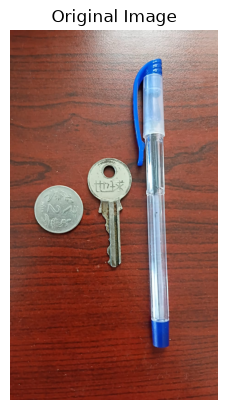

In [17]:
plt.imshow(rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [18]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [23]:
blur = cv2.GaussianBlur(gray, (5,5), 0)

In [24]:
edges = cv2.Canny(blur, 50, 150)

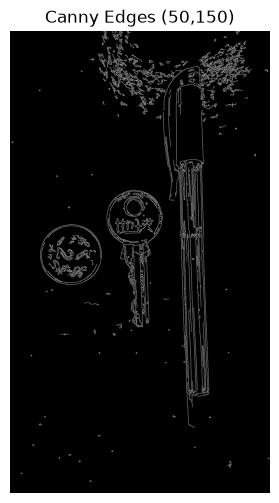

In [32]:
plt.figure(figsize=(6,6))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges (50,150)")
plt.axis("off")
plt.show()

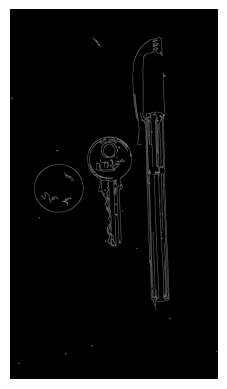

In [139]:
edges = cv2.Canny(blur,50, 270)
plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.show()

Initial Thresholds:
50,150

Objects Visible:
4

Second Attempt:
40,120

Objects Visible:
4

Third Attempt:
60,220

Objects visible:
11

Final Thresholds:
50,270

Number of Attempts:
4

In [140]:
contours, hierarchy = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

In [141]:
filtered_contours = []

for contour in contours:
    area = cv2.contourArea(contour)

    if area > 200:
        filtered_contours.append(contour)

In [142]:
count = len(filtered_contours)

print("Detected Objects:", count)

Detected Objects: 3


In [143]:
output = image.copy()

cv2.drawContours(
    output,
    filtered_contours,
    -1,
    (0,255,0),
    3
)

array([[[ 30,  42, 108],
        [ 30,  42, 108],
        [ 30,  42, 108],
        ...,
        [167, 176, 196],
        [167, 176, 196],
        [167, 176, 196]],

       [[ 30,  42, 108],
        [ 30,  42, 108],
        [ 30,  42, 108],
        ...,
        [165, 174, 194],
        [165, 174, 194],
        [165, 174, 194]],

       [[ 30,  42, 108],
        [ 30,  42, 108],
        [ 30,  42, 108],
        ...,
        [165, 174, 194],
        [165, 174, 194],
        [165, 174, 194]],

       ...,

       [[ 20,  34, 122],
        [ 20,  34, 122],
        [ 19,  33, 121],
        ...,
        [ 43,  60, 141],
        [ 43,  60, 141],
        [ 43,  60, 141]],

       [[ 20,  35, 121],
        [ 20,  35, 121],
        [ 19,  34, 120],
        ...,
        [ 42,  59, 140],
        [ 42,  59, 140],
        [ 42,  59, 140]],

       [[ 20,  35, 121],
        [ 20,  35, 121],
        [ 19,  34, 120],
        ...,
        [ 42,  59, 140],
        [ 42,  59, 140],
        [ 42,  59, 140]]

In [144]:
for i, contour in enumerate(filtered_contours):

    x, y, w, h = cv2.boundingRect(contour)

    cv2.putText(
        output,
        str(i+1),
        (x, y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255,0,0),
        2
    )

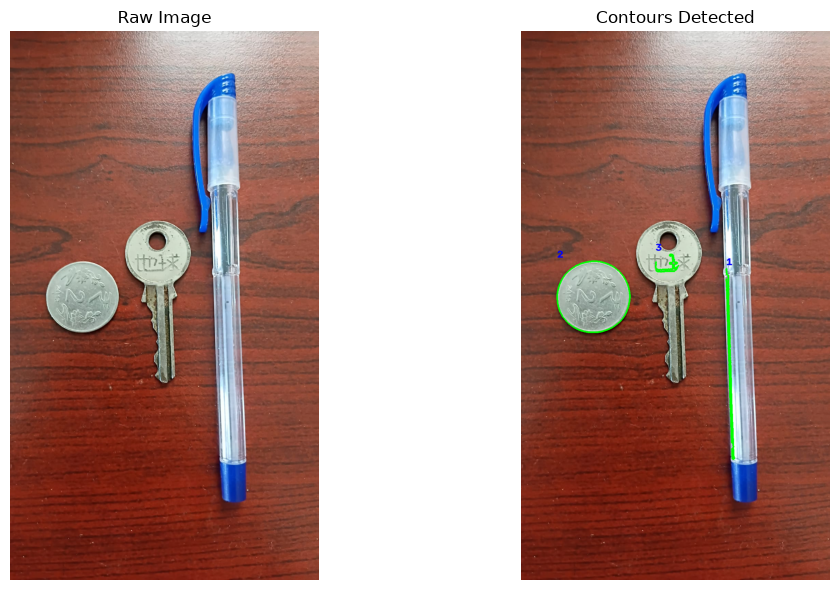

In [145]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title("Raw Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Contours Detected")
plt.axis("off")

plt.tight_layout()
plt.show()

Observation

The real number of objects in the image is 3 (pen, key, and coin).

Initially, using Canny thresholds (50,150), not all objects were detected clearly. After adjusting the thresholds, all three objects were visible.

The final thresholds used were:
Lower Threshold:50
Upper Threshold:270

It took 4 attempt(s) to obtain clear edges.

The contour detection identified 3 object(s).

After filtering out small contours using an area threshold, the detected count matched the actual count of 3 objects.

The annotated image clearly shows the detected contours around each object.